Mapping nhãn: {'no': np.int64(0), 'yes': np.int64(1)}

BẮT ĐẦU SO SÁNH 5 MODEL VỚI NGƯỠNG (THRESHOLD) = 0.6

--- Logistic Regression ---
Accuracy: 0.6205 | Recall: 0.8009 | Precision: 0.3995
--- SVM ---
Accuracy: 0.7295 | Recall: 0.0142 | Precision: 0.5000
--- Random Forest ---
Accuracy: 0.7256 | Recall: 0.0142 | Precision: 0.3333
--- XGBoost ---
Accuracy: 0.6897 | Recall: 0.3318 | Precision: 0.4094


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- LightGBM ---
Accuracy: 0.6859 | Recall: 0.4313 | Precision: 0.4213

===== BẢNG TỔNG KẾT CHI TIẾT =====
                 Model  Accuracy  Precision (Yes)  Recall (Yes)  F1-Score
0  Logistic Regression  0.620513         0.399527      0.800948  0.533123
4             LightGBM  0.685897         0.421296      0.431280  0.426230
3              XGBoost  0.689744         0.409357      0.331754  0.366492
1                  SVM  0.729487         0.500000      0.014218  0.027650
2        Random Forest  0.725641         0.333333      0.014218  0.027273


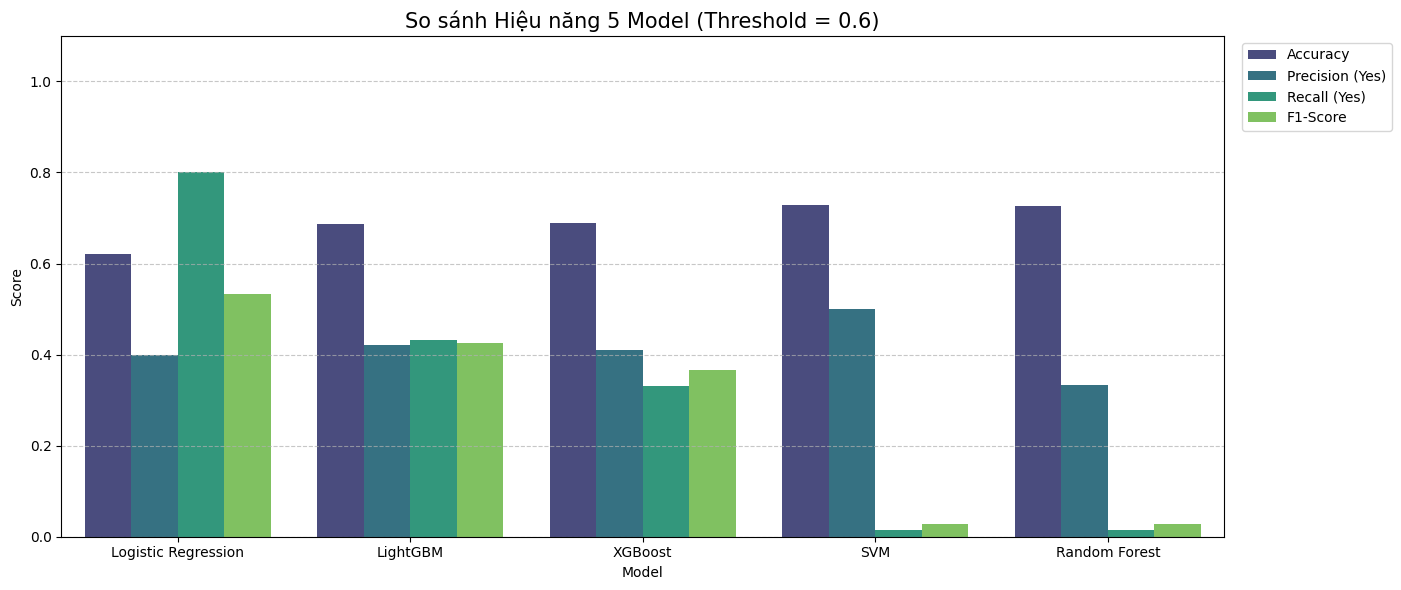

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

df = pd.read_csv('backend/shopping_behavior_updated.csv')

# 1. Chuẩn bị dữ liệu
TARGET_COL = "Subscription Status"
df[TARGET_COL] = df[TARGET_COL].astype(str).str.strip().str.lower()

# Mã hóa Label: yes -> 1, no -> 0
le = LabelEncoder()
y = le.fit_transform(df[TARGET_COL])
print(f"Mapping nhãn: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Bỏ cột Discount và Promo Code để mô hình không học vẹt
drop_cols = [
    "Customer ID", "Item Purchased", "Location", "Color", "Size", 
    "Promo Code Used", "Discount Applied", 
    TARGET_COL
]
X = df.drop(columns=drop_cols)

# 2. Preprocessing
numeric_features = ["Age", "Purchase Amount (USD)", "Review Rating", "Previous Purchases"]
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# Chia tập dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Tính toán tỷ lệ cân bằng cho XGBoost (số No / số Yes)
scale_pos_weight_val = (len(y_train) - sum(y_train)) / sum(y_train)

# 3. Cáuh hình các model
models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced', 
        max_iter=1000, 
        random_state=42
    ),
    "SVM": SVC(
        kernel='rbf', 
        class_weight='balanced', 
        probability=True,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, 
        class_weight='balanced', 
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        eval_metric='logloss', 
        scale_pos_weight=scale_pos_weight_val, # Thay thế class_weight
        random_state=42
    ),
    "LightGBM": LGBMClassifier(
        class_weight='balanced', 
        verbosity=-1, 
        random_state=42
    )
}

# 4. Huấn luyện và Đánh giá với threshold = 0.6
THRESHOLD = 0.6
results_data = []

print(f"\n{'='*60}")
print(f"BẮT ĐẦU SO SÁNH 5 MODEL VỚI NGƯỠNG (THRESHOLD) = {THRESHOLD}")
print(f"{'='*60}\n")

for name, model in models.items():
    clf = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
    
    # Huấn luyện
    clf.fit(X_train, y_train)
    
    if hasattr(clf, "predict_proba"):
        y_proba = clf.predict_proba(X_test)[:, 1]
    else:
        # Fallback cho SVM nếu quên probability=True
        y_proba = clf.decision_function(X_test)
        y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())

    # Nếu xác suất >= 0.6 thì mới là 1 (Yes), ngược lại là 0
    y_pred_threshold = (y_proba >= THRESHOLD).astype(int)
    
    acc = accuracy_score(y_test, y_pred_threshold)
    prec = precision_score(y_test, y_pred_threshold, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred_threshold, pos_label=1)
    f1 = f1_score(y_test, y_pred_threshold, pos_label=1)
    
    # Lưu kết quả
    results_data.append({
        "Model": name,
        "Accuracy": acc,
        "Precision (Yes)": prec,
        "Recall (Yes)": rec,
        "F1-Score": f1
    })
    
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f} | Recall: {rec:.4f} | Precision: {prec:.4f}")

# 5. Tổng hợp kết quả và trực quan hóa
results_df = pd.DataFrame(results_data).sort_values(by="F1-Score", ascending=False)

print("\n===== BẢNG TỔNG KẾT CHI TIẾT =====")
print(results_df)

plt.figure(figsize=(14, 6))

melted_df = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

sns.barplot(data=melted_df, x="Model", y="Score", hue="Metric", palette="viridis")
plt.title(f"So sánh Hiệu năng 5 Model (Threshold = {THRESHOLD})", fontsize=15)
plt.ylim(0, 1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

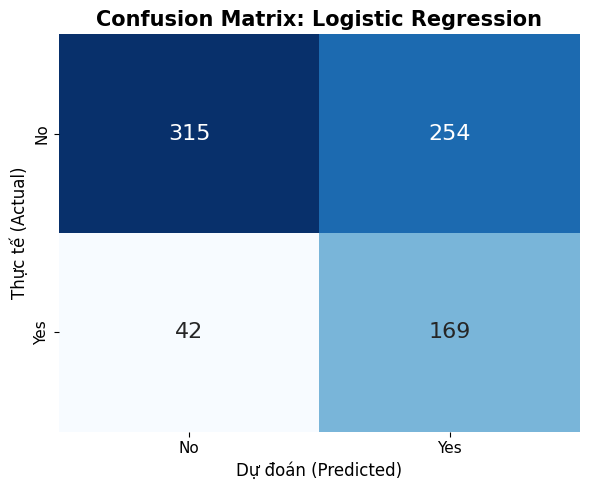

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ======================================================
# VẼ CONFUSION MATRIX CHO LOGISTIC REGRESSION
# ======================================================

# 1. Chọn đúng tên model bạn đã khai báo trong dictionary 'models'
MODEL_NAME = "Logistic Regression" 
THRESHOLD = 0.6

# Lấy model ra
model = models[MODEL_NAME]

# 2. Huấn luyện lại (để đảm bảo pipeline sạch)
clf = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
clf.fit(X_train, y_train)

# 3. Dự đoán xác suất
y_proba = clf.predict_proba(X_test)[:, 1]

# 4. Áp dụng ngưỡng (Threshold) để ra kết quả 0 hoặc 1
y_pred = (y_proba >= THRESHOLD).astype(int)

# 5. Tính toán Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 6. Vẽ biểu đồ
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})

plt.title(f"Confusion Matrix: {MODEL_NAME}", fontsize=15, fontweight='bold')
plt.xlabel('Dự đoán (Predicted)', fontsize=12)
plt.ylabel('Thực tế (Actual)', fontsize=12)
plt.xticks([0.5, 1.5], ['No', 'Yes'], fontsize=11)
plt.yticks([0.5, 1.5], ['No', 'Yes'], fontsize=11)

plt.tight_layout()
plt.show()